# Arabic Sentiment Analysis
**Birzeit University — Department of Electrical and Computer Engineering**  
**Second Semester 2025-2026 | Second Assignment**

---

**Dataset:** ASTD — Arabic Sentiment Tweets Dataset (3 classes: POS / NEG / NEUTRAL)  
**Goal:** Compare text representation methods and classifiers for Arabic sentiment analysis.

## Imports

In [163]:
# Add your imports here
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

## Load Dataset

The CSV file is in the same folder as this notebook. Load it and take a first look.

In [164]:
# Load the dataset from ASTD_arabic_sentiment.csv
df = pd.read_csv('ASTD_arabic_sentiment.csv')
print(f'Dataset shape: {df.shape}')

Dataset shape: (3315, 2)


---
# 1. Data Exploration

Understand the data before touching it. Things worth checking:
- How many rows and columns?
- Are there missing values?
- How many samples per class? Is the dataset balanced?
- What does the raw Arabic text look like?
- How long are the tweets (word count)?

In [165]:
# Basic structure: shape, dtypes, missing values
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3315 entries, 0 to 3314
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    3315 non-null   str  
 1   label   3315 non-null   str  
dtypes: str(2)
memory usage: 51.9 KB
None


- As we can see there are 2 columns, the first column being the text (the post/tweet from the users), and the second column is the label, where the label is what determines under what category/class the tweet falls under. Thankfully no null values yet, however that may change once we process the tweet for stop words or other characters that may be removed.

<Axes: >

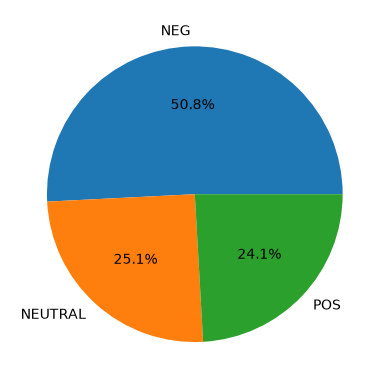

In [166]:
# Class distribution — count and proportion
distribution = df['label'].value_counts()
# plot the distribution as a pie chart 
distribution.plot(kind='pie', autopct='%1.1f%%')

As we can see here the data is mostly negative (Imbalanced), where the rest is almost a fair split between positive and neutral. 

In [167]:
# Print a few sample tweets per class
for label in df['label'].unique():
    samples = df[df['label'] == label]['text'].head(2).tolist()
    print(f'\n{label}:')
    for sample in samples:
        print(sample)
    print ('='*90)


POS:
أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر، بمناسبة صدور أولى روايته
امير عيد هو اللي فعلا يتقال عليه ستريكر صريح #كاريوكي #السكة_شمال

NEG:
البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام العريان الي واشنطن شئ مقرف
عودة جماعة الإخوان إلى الحياة السياسية بنفس وضعها السابق مستحيلة والطرمخة على جرائم الماضي لن تجعلنا نتقدم شبرا

NEUTRAL:
الوالدة لو اقولها بخاطري حشيشة تضحك بس من اقولها ملل الله وكيلك تعطيني محاضرة عن الفسق والفجور بجنوب الشيشان #ليه كذا يانبع الحنان
#انتخبوا_العرص #انتخبوا_البرص #مرسى_رئيسى #اين_رئيسى #_ #__ö


/var/folders/h8/nxtdnck576l4tt1xrc13853c0000gp/T/ipykernel_20739/3549487413.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y='word_count',
/var/folders/h8/nxtdnck576l4tt1xrc13853c0000gp/T/ipykernel_20739/3549487413.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='word_count',


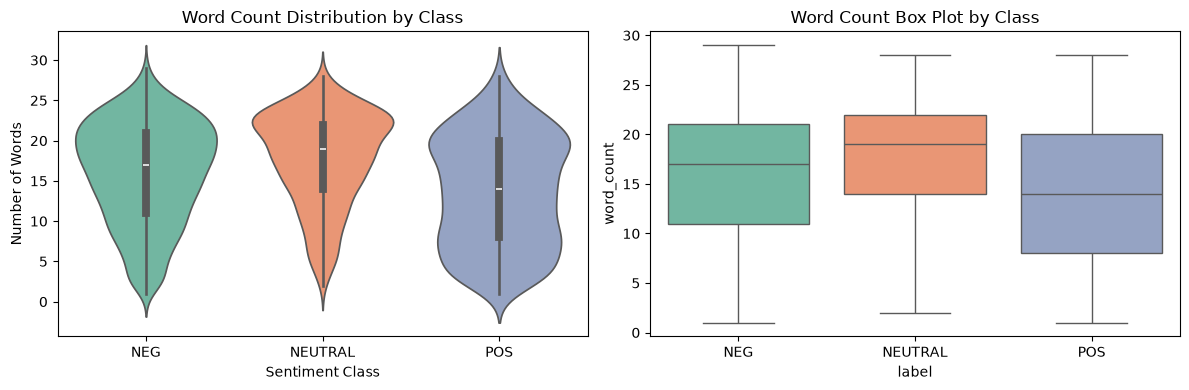

In [168]:
# Tweet length distribution (word count) — visualise with histogram and/or box plot
df['word_count'] = df['text'].str.split().str.len()



fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram: distribution of tweet lengths separated by sentiment class.
# Overlapping distributions suggest that length alone doesn't predict sentiment.
sns.violinplot(data=df, x='label', y='word_count',
               order=['NEG', 'NEUTRAL', 'POS'], palette='Set2', ax=axes[0])
axes[0].set_title('Word Count Distribution by Class')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Number of Words')

# Box plot: median, interquartile range, and outliers per class more clearly.
sns.boxplot(data=df, x='label', y='word_count',
            order=['NEG', 'NEUTRAL', 'POS'], palette='Set2', ax=axes[1])
axes[1].set_title('Word Count Box Plot by Class')

plt.tight_layout()
plt.show()

### Observation
As we can see from the violin plot, the length of the text feature does not have a direct link to the target class, so it is difficult to attain any value from the length as they all are around the same size except for the positive which slightly has more counts in the lower counts.

---
# 2. Data Preprocessing

Arabic social media text requires specific cleaning steps before feeding it to any model:

| Step | What to do |
|---|---|
| Noise removal | Remove URLs, HTML tags, @mentions, hashtag symbols, emojis, Latin/digits |
| Tashkeel | Remove short vowel diacritics (rarely appear on social media, inflate vocab) |
| Tatweel | Remove the elongation character ـ |
| Alef normalisation | Map أ / إ / آ → ا |
| Yeh normalisation | Map ى → ي |
| Teh Marbuta | Map ة → ه |
| Non-Arabic removal | Keep only Arabic Unicode range (U+0600–U+06FF) |
| Stop words | Remove common function words with no sentiment value |

Write a `preprocess_arabic(text)` function that applies all these steps.

In [169]:
# Arabic stop words — negation words (لا، لم، ليس، ليست، ولا، ولم) are intentionally excluded
# because removing them flips sentiment (e.g. "لا أحب" → "أحب" changes "I don't like" to "I like")
ARABIC_STOP_WORDS = {
    'في', 'من', 'إلى', 'على', 'أن', 'هذا', 'هذه', 'ذلك', 'التي', 'الذي',
    'وفي', 'وقد', 'كان', 'ما', 'مع', 'بين', 'عن', 'قد', 'كل',
    'له', 'بعد', 'قبل', 'وهو', 'وهي', 'أو', 'هو', 'هي', 'نحن',
    'أنا', 'أنت', 'هم', 'هن', 'عند', 'أيضا', 'حتى', 'إذا', 'لكن',
    'يكون', 'كانت', 'وكان', 'يمكن', 'الذين', 'غير', 'بشكل', 'حيث',
    'بما', 'كما', 'تم', 'مما', 'إن', 'وأن', 'ومن', 'عبر',
    'لأن', 'أنه', 'ذات', 'بل', 'ثم', 'اي', 'أي', 'ال', 'و',
    'ب', 'ل', 'ف', 'ك', 'هل', 'لي', 'لك', 'لنا', 'لهم', 'منه',
    'منها', 'فيه', 'فيها', 'وكل', 'سوف', 'اذ', 'إذ', 'كيف', 'متى',
    'أين', 'انا', 'انت', 'الان', 'الآن', 'ولكن',
    'هناك', 'وهذا', 'وهذه', 'كانوا', 'قالوا', 'وقال', 'وقالت',
    'عليه', 'عليها', 'فقط', 'عليهم', 'لهذا', 'بهذا', 'كذلك',
    'وأيضا', 'مثل', 'وعلى', 'وعن', 'عنه', 'عنها', 'وهم', 'وله',
}

def preprocess_arabic(text: str) -> str:
    if not isinstance(text, str):
        return ''

    # Step 1: Remove web/social noise — must come before punctuation stripping
    # so that @mentions and #hashtags are matched whole before @ and # are removed
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # URLs
    text = re.sub(r'<[^>]+>', '', text)                   # HTML tags
    text = re.sub(r'@\w+', '', text)                      # @mentions
    text = re.sub(r'#(\S+)', r'\1', text)                 # strip # but keep word

    # Step 2: Remove diacritics and decorative characters
    text = re.sub(r'[ً-ٰٟ]', '', text)    # tashkeel (short vowels)
    text = re.sub(r'ـ', '', text)                    # tatweel (elongation ـ)

    # Step 3: Remove Arabic punctuation (،, ؛, ؟ are inside Arabic range so need explicit removal)
    text = re.sub(r'[؀-،؛؟٪-٭۔]', ' ', text)

    # Step 4: Normalize Arabic character variants
    text = re.sub(r'[إأآ]', 'ا', text)   # Alef variants → ا
    text = re.sub(r'ى', 'ي', text)        # Alef Maqsura → Yeh
    text = re.sub(r'ة', 'ه', text)        # Teh Marbuta → Heh
    text = re.sub(r'ؤ', 'و', text)        # Waw with hamza → Waw
    text = re.sub(r'ئ', 'ي', text)        # Yeh with hamza → Yeh

    # Step 5: Keep only Arabic letters and whitespace
    text = re.sub(r'[^ء-غف-ي\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 6: Remove stop words and single-character tokens
    words = [w for w in text.split() if w not in ARABIC_STOP_WORDS and len(w) > 1]
    return ' '.join(words)

In [170]:
# Apply the cleaning function row-by-row to the 'text' column.
df['text_clean'] = df['text'].apply(preprocess_arabic)

# Visual before/after check — lets us verify the pipeline is working as intended.
print('Before / After examples:')
print('='*90)
for i in range(3):
    print(f'\n[{df["label"].iloc[i]}]')
    print(f'  BEFORE: {df["text"].iloc[i]}')
    print(f'  AFTER:  {df["text_clean"].iloc[i]}')


Before / After examples:

[POS]
  BEFORE: أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر، بمناسبة صدور أولى روايته
  AFTER:  اهني الدكتور احمد جمال الدين القيادي بحزب مصر بمناسبه صدور اولي روايته

[NEG]
  BEFORE: البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام العريان الي واشنطن شئ مقرف
  AFTER:  البرادعي يستقوي بامريكا مرهاخري يرسل عصام العريان الي واشنطن شي مقرف

[NEUTRAL]
  BEFORE: الوالدة لو اقولها بخاطري حشيشة تضحك بس من اقولها ملل الله وكيلك تعطيني محاضرة عن الفسق والفجور بجنوب الشيشان #ليه كذا يانبع الحنان
  AFTER:  الوالده لو اقولها بخاطري حشيشه تضحك بس اقولها ملل الله وكيلك تعطيني محاضره الفسق والفجور بجنوب الشيشان ليه كذا يانبع الحنان


In [171]:
empty = (df['text_clean'].str.strip() == '').sum()
print(f'\nEmpty texts after preprocessing: {empty}')
df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)
print(f'Remaining samples: {len(df)}')

df['text_clean'].info()


Empty texts after preprocessing: 5
Remaining samples: 3310
<class 'pandas.Series'>
RangeIndex: 3310 entries, 0 to 3309
Series name: text_clean
Non-Null Count  Dtype
--------------  -----
3310 non-null   str  
dtypes: str(1)
memory usage: 26.0 KB


In [ ]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'NEG': np.int64(0), 'NEUTRAL': np.int64(1), 'POS': np.int64(2)}


### Observations

All noise that was deemed unneccessary was removed, hashtags, stop words (words that dont give true meaning becuase they are so common in the language), whitespaces, latin characters, etc...
I have also converted the labels to numeric values to help with the training. 
A handful of rows were dropped which is a good sign for the data quality as of now.
# Emoji Demojization
Although Emojis do provide sentiment, the amount of preprocessing to do so will overcomplicate and take too much effort, I have thought of an effort to make it where we convert emoji to its name and then convert the name to its arabic translation. However that requires too much effort. I do recommend to just remove it and keep it strictly words for now to keep the assignment simple.


---
# 3. Dataset Splitting

Split into **60% train / 20% validation / 20% test** using stratified sampling so each split has the same class proportions.

In [199]:
# Two-step stratified split: 60% train, then 50/50 on the remaining 40%

X = df['text_clean'].to_numpy()
y = df['label_enc'].to_numpy()

# Step 1: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

# Step 2: split temp 50/50 → 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f'Train:      {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)')
print(f'Validation: {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)')
print(f'Test:       {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)')

def print_class_balance(y, name):
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    print(f'\n{name} ({total} samples):')
    for label, count in zip(unique, counts):
        print(f'  {le.classes_[label]}: {count} ({count/total*100:.1f}%)')

print_class_balance(y_train, 'Train')
print_class_balance(y_val, 'Validation')
print_class_balance(y_test, 'Test')

Train:      1986 (60.0%)
Validation: 662 (20.0%)
Test:       662 (20.0%)

Train (1986 samples):
  NEG: 1010 (50.9%)
  NEUTRAL: 498 (25.1%)
  POS: 478 (24.1%)

Validation (662 samples):
  NEG: 336 (50.8%)
  NEUTRAL: 166 (25.1%)
  POS: 160 (24.2%)

Test (662 samples):
  NEG: 337 (50.9%)
  NEUTRAL: 166 (25.1%)
  POS: 159 (24.0%)
